Section 1: Import Libraries


Section 2: Load Dataset


Section 3: Dataset Overview


Section 4: Strong Numerical Summaries


Section 5: Overall Stroke Prevalence


Section 6: Stroke Rate by Age Group


Section 7: Stroke Rate by Gender


Section 8: Stroke Rate by Marital Status


Section 9: Stroke Rate by Work Type


Section 10: Stroke Rate by Residence Type


Section 11: Hypertension vs Stroke


Section 12: Heart Disease vs Stroke


Section 13: Glucose Distribution by Stroke Status


Section 14: BMI Distribution by Stroke Status


Section 15: Smoking Status vs Stroke Rate


Section 16: Correlation Heatmap


Section 17: NEW Combined Analysis


Section 18: Final EDA Summary for Modelling

In [59]:
# ==========================================
# SECTION 1: IMPORT LIBRARIES
# ==========================================

# pandas -> data manipulation and analysis
import pandas as pd

# numpy -> numerical operations
import numpy as np

# matplotlib -> basic visualizations
import matplotlib.pyplot as plt

# seaborn -> statistical visualizations
import seaborn as sns

# Improve chart appearance
plt.style.use("default")
# Load cleaned dataset produced in Issue #3



In [60]:
# ==========================================
# SECTION 2: LOAD CLEANED DATASET
# ==========================================

# Load the cleaned dataset produced in Issue #3.
# This dataset already has missing BMI values handled
# and the ID column removed.

df = pd.read_csv(
    "/content/drive/MyDrive/PERSONAL PROJECTS/MENTORSHIP PROJECTS/1 Stroke Risk Prediction & Clinical Insights Analysis/stroke_cleaned.csv"
)

# Display first five rows.

df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# **Section 3: Dataset Overview and Numerical Summaries**

**Business Question**

What does the dataset look like, and how do the numerical characteristics differ between patients who experienced a stroke and those who did not?


**Why This Analysis Matters**

Before creating visualisations, we need to understand the structure and characteristics of the dataset.


**Numerical summaries help us**:

Understand the size of the dataset
Identify the types of variables
Compare average age, glucose level, and BMI between stroke and non-stroke patients
Identify variables that may be important predictors during modelling

In [61]:
# ==========================================
# DATASET DIMENSIONS
# ==========================================

# View the number of rows and columns.
#
# shape returns:
# (number of rows, number of columns)
#
# This helps us understand the size of
# the dataset before analysis begins.

df.shape

(5110, 11)

In [62]:
# INTERPRETATION

# The dataset contains:
# - 5,110 patient records (rows)
# - 11 variables (columns)
#
# Each row represents one patient.
# Each column represents one demographic,
# lifestyle, or clinical characteristic.

In [63]:
# ==========================================
# COLUMN NAMES
# ==========================================

# Display all variable names in the dataset.
#
# This allows us to become familiar with
# the information available for analysis.

df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [64]:
# INTERPRETATION

# The dataset contains variables describing:

# Demographics:
# gender, age, ever_married, Residence_type

# Clinical information:
# hypertension, heart_disease,
# avg_glucose_level, bmi

# Lifestyle factors:
# smoking_status, work_type

# Outcome variable:
# stroke

In [65]:
# ==========================================
# DATA TYPES
# ==========================================

# Display information about every column.
#
# info() shows:
# - number of non-null values
# - data types
# - memory usage
#
# Understanding data types is important
# because different variable types require
# different analytical techniques.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [66]:
# INTERPRETATION

# The dataset contains both:

# Numerical variables:
# age
# hypertension
# heart_disease
# avg_glucose_level
# bmi
# stroke

# Categorical variables:
# gender
# ever_married
# work_type
# Residence_type
# smoking_status

# The mixture of numerical and categorical
# variables makes this dataset suitable for
# both exploratory analysis and predictive
# modelling.

# **Section 4: Numerical Summary of Stroke vs Non-Stroke Patients**

**Business Question**

How do age, glucose level, and BMI differ between patients who had a stroke and those who did not?


**Why This Analysis Matters**

Charts help us see patterns visually, but descriptive statistics provide numerical evidence.

If stroke patients are substantially older or have higher glucose levels or BMI values, these variables may become important predictors during modelling.

In [67]:
# ==========================================
# NUMERICAL SUMMARY OF STROKE VS NON-STROKE
# ==========================================

# Group patients into:
# stroke = 0 (No Stroke)
# stroke = 1 (Stroke)

# describe() calculates:
# count
# mean
# standard deviation
# minimum
# quartiles
# maximum

# We focus on:
# age
# avg_glucose_level
# bmi

stroke_summary = (
    df.groupby("stroke")[
        ["age", "avg_glucose_level", "bmi"]
    ]
    .describe()
)

stroke_summary

age                                                      \
         count       mean        std   min   25%   50%   75%   max   
stroke                                                               
0       4861.0  41.971545  22.291940  0.08  24.0  43.0  59.0  82.0   
1        249.0  67.728193  12.727419  1.32  59.0  71.0  78.0  82.0   

       avg_glucose_level              ...                     bmi             \
                   count        mean  ...     75%     max   count       mean   
stroke                                ...                                      
0                 4861.0  104.795513  ...  112.83  267.76  4861.0  28.799115   
1                  249.0  132.544739  ...  196.71  271.74   249.0  30.090361   

                                                
             std   min   25%   50%   75%   max  
stroke                                          
0       7.777269  10.3  23.6  28.1  32.8  97.6  
1       5.861877  16.9  27.0  28.1  32.5  56.6  

[2 rows x 24 columns]

In [68]:
# =====================================================
# INTERPRETATION OF NUMERICAL SUMMARY
# =====================================================

# AGE
# Patients who experienced a stroke are considerably older
# than patients who did not experience a stroke.

# Mean age:
# - No Stroke (0): 41.97 years
# - Stroke (1): 67.73 years

# Median age:
# - No Stroke (0): 43 years
# - Stroke (1): 71 years

# This suggests that age has a strong association with
# stroke occurrence in this dataset. Older adults appear
# to have a substantially higher risk of experiencing stroke.


# AVERAGE GLUCOSE LEVEL
# Patients who experienced a stroke also have noticeably
# higher glucose levels.

# Mean glucose level:
# - No Stroke (0): 104.80
# - Stroke (1): 132.54

# Median glucose level:
# - No Stroke (0): 91.88
# - Stroke (1): 105.22

# This finding suggests that elevated blood glucose levels
# may be an important predictor of stroke risk.


# BMI
# Stroke patients have a slightly higher average BMI.

# Mean BMI:
# - No Stroke (0): 28.80
# - Stroke (1): 30.09

# Median BMI:
# - No Stroke (0): 28.1
# - Stroke (1): 28.1

# Although stroke patients have a somewhat higher average BMI,
# the difference is much smaller than what we observed for age
# and glucose levels.

# This suggests that BMI may contribute to stroke risk,
# but its relationship with stroke appears weaker than age
# and glucose level in this dataset.


# OVERALL IMPLICATIONS FOR MODELLING
# Based on these numerical summaries:

# 1. Age appears to be the strongest predictor of stroke occurrence.
# 2. Average glucose level also shows a meaningful association with stroke.
# 3. BMI shows a weaker but potentially useful relationship with stroke.

# These findings suggest that age, average glucose level,
# and BMI should be retained during feature engineering
# and predictive modelling because they contain potentially
# important information for predicting stroke risk.

# **Section 5: Overall Stroke Prevalence**

**Business Question**


How many patients experienced a stroke and how many did not?

**Why This Analysis Matters**


Understanding the distribution of the target variable (stroke) is extremely important before building machine learning models.

If one class is much smaller than the other, the dataset is said to be imbalanced.

Class imbalance can lead to misleading model performance because a model may simply predict the majority class most of the time and still achieve high accuracy.

Therefore, we need to quantify and visualize the distribution of stroke cases before proceeding with modelling.

In [69]:
# =====================================================
# COUNT STROKE CASES
# =====================================================

# Count how many patients belong to each stroke category.
#
# stroke = 0 means No Stroke
# stroke = 1 means Stroke
#
# value_counts() counts the number of occurrences
# of each value in the stroke column.

stroke_counts = df["stroke"].value_counts()

# Display results
stroke_counts

,count
stroke,
0,4861
1,249


In [70]:
# =====================================================
# INTERPRETATION OF STROKE COUNTS
# =====================================================

# The dataset contains a total of 5,110 patient records.

# Out of these patients:
# - 4,861 patients did not experience a stroke (stroke = 0)
# - 249 patients experienced a stroke (stroke = 1)

# This means that patients without stroke greatly outnumber
# patients with stroke in the dataset.

# At this stage, we can already suspect that the dataset
# may be imbalanced because the positive stroke cases
# appear to represent only a small fraction of all patients.

# We will calculate percentages next to determine the
# exact degree of class imbalance.

In [71]:
# =====================================================
# CALCULATE STROKE PERCENTAGES
# =====================================================

# Convert counts into percentages.
#
# normalize=True converts counts into proportions.
#
# Multiplying by 100 converts proportions into percentages.

stroke_percentages = (
    df["stroke"]
      .value_counts(normalize=True)
      * 100
)

# Display percentages
stroke_percentages

,proportion
stroke,
0,95.127202
1,4.872798


In [72]:
# INTERPRETATION

# Percentages are easier to interpret than raw counts.

# We expect approximately:

# Stroke = 0 : 95.13%
# Stroke = 1 : 4.87%

# This indicates that stroke cases represent
# only a small proportion of the dataset.

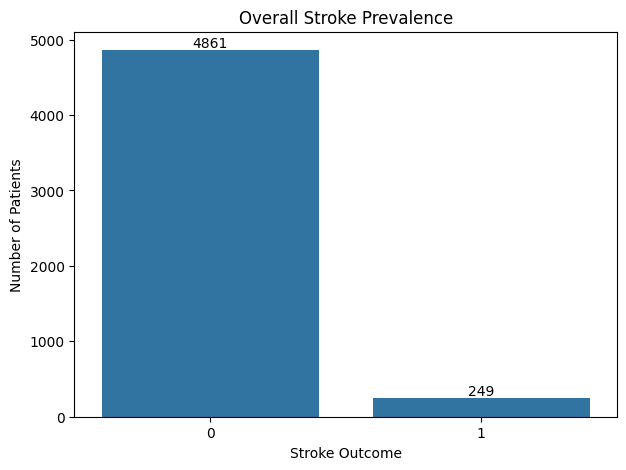

In [73]:
# =====================================================
# VISUALIZE STROKE PREVALENCE
# =====================================================

# Create chart area.

plt.figure(figsize=(7, 5))

# Create count plot.
#
# countplot automatically counts observations
# in each category.

ax = sns.countplot(
    data=df,
    x="stroke"
)

# Add chart title.

plt.title(
    "Overall Stroke Prevalence"
)

# Label axes.

plt.xlabel("Stroke Outcome")
plt.ylabel("Number of Patients")

# Add count labels above each bar.
# This makes the chart easier to read.

for container in ax.containers:
    ax.bar_label(container)

# Display chart.

plt.show()

In [74]:
# =====================================================
# INTERPRETATION OF STROKE PREVALENCE
# =====================================================

# The dataset is highly imbalanced.

# Approximately:
# - 95.13% of patients did not experience stroke.
# - 4.87% of patients experienced stroke.

# In other words, only 249 out of 5,110 patients
# belong to the positive stroke class.

# This imbalance has important implications
# for predictive modelling.

# For example, a model that predicts
# "No Stroke" for every patient would achieve
# approximately 95% accuracy while failing to
# identify any actual stroke cases.

# Therefore, accuracy alone may be misleading
# when evaluating model performance.

# Metrics such as:
# - Recall
# - Precision
# - F1-score
# - ROC AUC

# will be more informative than accuracy alone.

# The class imbalance also suggests that
# special handling techniques may be needed
# during modelling to improve the model's
# ability to identify stroke cases.

# **Section 6: Stroke Rate by Age Group**


**## Business Question**

How does stroke occurrence vary across different age groups?


**## Why This Analysis Matters**

Age is one of the strongest known risk factors for stroke.

Grouping patients into age categories allows us to understand whether stroke prevalence increases as patients get older.

This analysis may help identify high-risk age segments that should receive earlier screening and preventive interventions.

In [75]:
# =====================================================
# CREATE AGE GROUPS
# =====================================================

# Continuous age values can sometimes be difficult
# to interpret directly.

# Therefore, we divide age into meaningful groups.

# The age bands are:
# 0–18 years
# 19–35 years
# 36–50 years
# 51–65 years
# 66 years and above

# Define age boundaries.

bins = [0, 18, 35, 50, 65, 100]

# Define labels.

labels = [
    "0-18",
    "19-35",
    "36-50",
    "51-65",
    "66+"
]

# Create new age_group column.

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels
)

# View first few observations.

df[["age", "age_group"]].head()

,age,age_group
0,67.0,66+
1,61.0,51-65
2,80.0,66+
3,49.0,36-50
4,79.0,66+


In [76]:
# INTERPRETATION

# Age is a continuous variable.

# Creating age groups makes the analysis easier
# to understand and communicate.

# Healthcare professionals often think in terms of
# age categories rather than individual ages.

# These categories will also be useful later
# during feature engineering and reporting.

In [77]:
# =====================================================
# CALCULATE STROKE RATE BY AGE GROUP
# =====================================================

# Group patients according to age group.

# The stroke column is binary:
# 0 = No Stroke
# 1 = Stroke

# The mean of a binary variable equals
# the proportion of positive cases.

# Multiplying by 100 converts proportions
# into percentages.

age_stroke_rate = (
    df.groupby("age_group")["stroke"]
      .mean()
      * 100
)

# Display results.

age_stroke_rate

/tmp/ipykernel_1877/1541430412.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["stroke"]


,stroke
age_group,
0-18,0.218341
19-35,0.101729
36-50,1.845018
51-65,6.024096
66+,16.165803


In [78]:
# =====================================================
# INTERPRETATION OF AGE GROUP ANALYSIS
# =====================================================

# The results show a very clear increase in stroke
# prevalence as age increases.

# Stroke rates by age group are:

# - 0-18 years: 0.22%
# - 19-35 years: 0.10%
# - 36-50 years: 1.85%
# - 51-65 years: 6.02%
# - 66+ years: 16.17%

# Patients aged 66 years and above have the highest
# stroke rate (16.17%), which means approximately
# 16 out of every 100 patients in this age group
# experienced a stroke.

# In comparison, stroke rates among younger patients
# are extremely low, remaining below 2% for all
# age groups below 51 years.

# This finding is consistent with our earlier
# numerical summary where stroke patients had
# an average age of approximately 68 years,
# compared with approximately 42 years among
# patients who did not experience a stroke.

# The analysis suggests that age is one of the
# strongest predictors of stroke occurrence
# in this dataset.

# However, this analysis demonstrates association
# rather than causation.

# Older patients are also more likely to have
# other risk factors such as hypertension,
# heart disease, and elevated glucose levels,
# which may contribute to the higher stroke rates.

# Therefore, age should be retained as an
# important variable during feature engineering
# and predictive modelling.

# **SECTION 7: Stroke Rate by Gender**

**Business Question**

Does stroke prevalence differ across genders?

**Why This Matters**

Although gender itself may not directly cause stroke, understanding differences across genders can reveal demographic patterns that may be useful during exploratory analysis and predictive modelling.

In [79]:
# =====================================================
# CALCULATE STROKE RATE BY GENDER
# =====================================================

gender_stroke = (
    df.groupby("gender")["stroke"]
      .mean()
      * 100
)

gender_stroke

,stroke
gender,
Female,4.709419
Male,5.106383
Other,0.000000


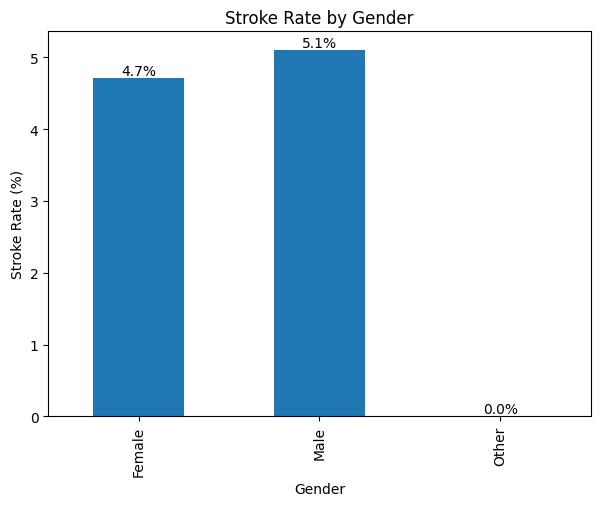

In [80]:
plt.figure(figsize=(7, 5))

ax = gender_stroke.plot(
    kind="bar"
)

plt.title(
    "Stroke Rate by Gender"
)

plt.xlabel("Gender")
plt.ylabel("Stroke Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.show()

In [81]:
# =====================================================
# INTERPRETATION OF GENDER ANALYSIS
# =====================================================

# Stroke prevalence differs slightly
# across gender categories.

# However, the differences are much smaller
# than what was observed for age.

# This suggests that gender may contribute
# some predictive information but is
# unlikely to be as important as age,
# glucose level, or clinical factors.

# The findings represent associations
# within this dataset and should not
# be interpreted as evidence that
# gender causes stroke.

# Gender will be retained during modelling
# because even weak predictors can contribute
# useful information when combined with
# other variables.

# **Section 8: Stroke Rate by Marital Status**


## **Business Question**

Does stroke prevalence differ between patients who have ever been married and those who have never been married?

## **Why This Analysis Matters**

Marital status is a demographic characteristic that may show differences in stroke prevalence across patient groups. Examining these differences helps us identify potential patterns within the dataset.

However, it is important to interpret the findings carefully. Marital status itself is unlikely to directly influence stroke occurrence. Instead, other factors such as age may explain any observed differences because older individuals are more likely to have been married and age is already known to be strongly associated with stroke risk.

Therefore, this analysis should be viewed as an exploration of associations rather than evidence of causation.


In [82]:
married_stroke = (
    df.groupby("ever_married")["stroke"]
      .mean()
      * 100
)

married_stroke

,stroke
ever_married,
No,1.650541
Yes,6.561288


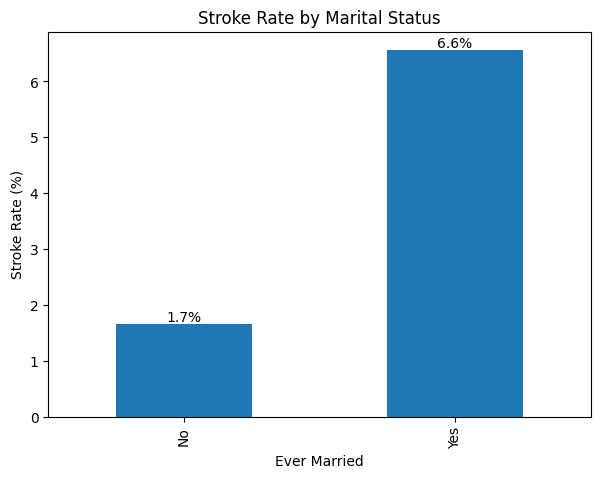

In [83]:
plt.figure(figsize=(7, 5))

ax = married_stroke.plot(
    kind="bar"
)

plt.title(
    "Stroke Rate by Marital Status"
)

plt.xlabel("Ever Married")
plt.ylabel("Stroke Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.show()

In [84]:
# =====================================================
# INTERPRETATION OF MARITAL STATUS ANALYSIS
# =====================================================

# Stroke rates may differ between patients
# who have ever been married and those
# who have never been married.

# However, this finding should be interpreted
# cautiously.

# Marital status itself is unlikely to
# directly influence stroke occurrence.

# A more plausible explanation is that
# older individuals are more likely to
# have been married and age is already
# strongly associated with stroke risk.

# Therefore, age may be acting as a
# confounding variable in this relationship.



## **Section 9: Stroke Rate by Work Type**


## **Business Question**
Does stroke prevalence differ across different employment categories?

## **Why This Analysis Matters**

Occupation may reflect differences in age distribution, socioeconomic factors, daily activity levels, stress exposure, and access to healthcare.

However, differences observed across work categories should be interpreted cautiously. Certain work groups, such as children and retired individuals, have very different age distributions, and age itself is a major stroke risk factor.

Therefore, this analysis explores associations rather than causal relationships.

In [85]:
# =====================================================
# CALCULATE STROKE RATE BY WORK TYPE
# =====================================================

# Group patients according to work type.

# The stroke column is binary:
# 0 = No Stroke
# 1 = Stroke

# The mean of a binary variable gives
# the proportion of stroke cases.

# Multiply by 100 to convert proportions
# into percentages.

work_stroke_rate = (
    df.groupby("work_type")["stroke"]
      .mean()
      * 100
)

# Display results.

work_stroke_rate

,stroke
work_type,
Govt_job,5.022831
Never_worked,0.000000
Private,5.094017
Self-employed,7.936508
children,0.291121


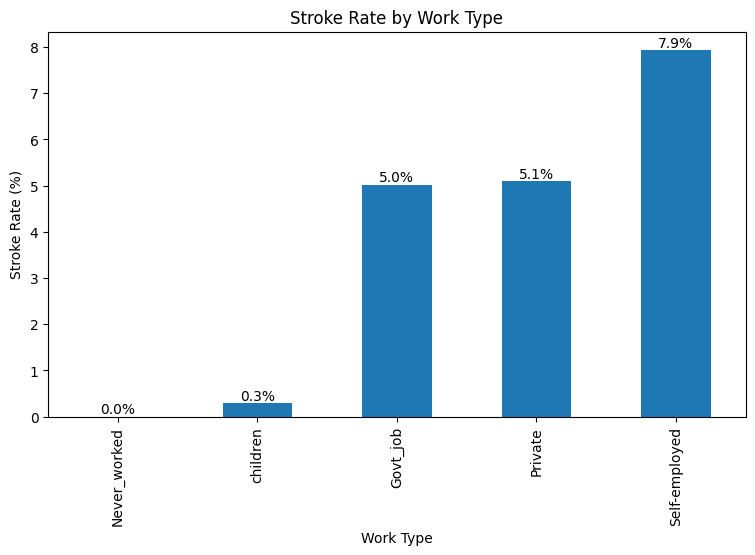

In [86]:
# =====================================================
# VISUALIZE STROKE RATE BY WORK TYPE
# =====================================================

plt.figure(figsize=(9,5))

ax = work_stroke_rate.sort_values().plot(
    kind="bar"
)

plt.title("Stroke Rate by Work Type")
plt.xlabel("Work Type")
plt.ylabel("Stroke Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

In [87]:
# =====================================================
# INTERPRETATION OF WORK TYPE ANALYSIS
# =====================================================

# Stroke rates vary across work categories.

# However, work type should not be interpreted
# as a direct cause of stroke.

# Age is likely to be a major confounding factor.

# For example:
# - The children category contains mostly young individuals.
# - Self-employed individuals may contain a higher proportion
#   of older adults.

# Therefore, differences in stroke rates may partly reflect
# differences in age distributions rather than employment
# status itself.

# Work type may still contain useful predictive information
# and will therefore be retained for modelling.

# **Additional Investigation: Is Age Confounding the Relationship Between Work Type and Stroke?**

The differences in stroke rates across work categories may be influenced by age.

Categories such as "children" naturally contain younger individuals, while categories such as "Self-employed" may contain a larger proportion of older adults.

To investigate whether age may partly explain these differences, we will examine the average age within each work category.

In [88]:
# =====================================================
# CHECK WHETHER AGE MAY BE CONFOUNDING WORK TYPE
# =====================================================

# Calculate the average age for each work category.
#
# If categories with higher stroke rates also
# have older average ages, it suggests that age
# may be influencing the relationship between
# work type and stroke.

average_age_by_work = (
    df.groupby("work_type")["age"]
      .mean()
      .sort_values()
)

average_age_by_work

,age
work_type,
children,6.841339
Never_worked,16.181818
Private,45.503932
Govt_job,50.879756
Self-employed,60.201465


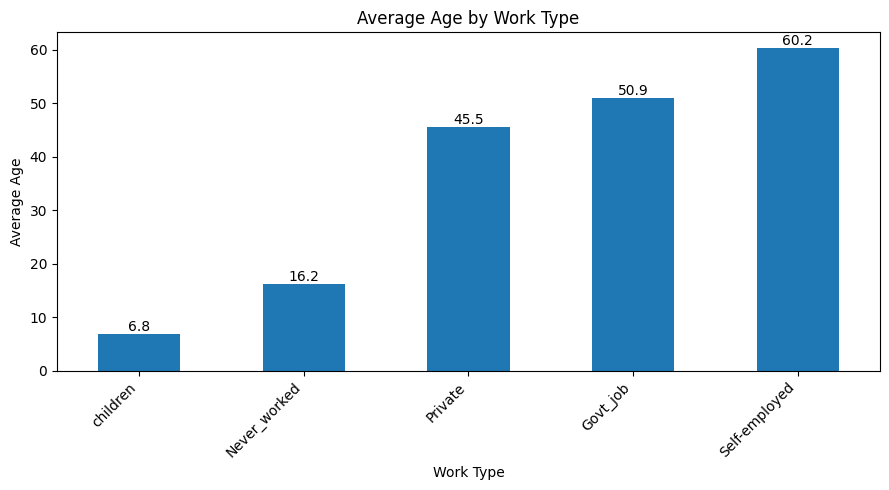

In [89]:
plt.figure(figsize=(9,5))

ax = average_age_by_work.plot(
    kind="bar"
)

plt.title("Average Age by Work Type")
plt.xlabel("Work Type")
plt.ylabel("Average Age")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [90]:
# INTERPRETATION

# Categories such as children and never_worked
# have much younger average ages.

# Categories such as self-employed have
# considerably higher average ages.

# This provides evidence that age may partly
# explain the observed differences in stroke
# rates across work categories.

# Therefore, work type should not be interpreted
# as directly causing stroke risk.

# Instead, work type may be acting as a proxy
# for age differences within the dataset.

## **Section 10: Stroke Rate by Residence Type**


## **Business Question**
Does stroke prevalence differ between patients living in urban and rural areas?

## **Why This Analysis Matters**

Residence type may reflect differences in lifestyle, healthcare access, environmental factors, and socioeconomic conditions.

However, residence type alone is unlikely to directly determine stroke risk. Observed differences may also be influenced by age, health status, and other underlying factors.

In [91]:
# =====================================================
# CALCULATE STROKE RATE BY RESIDENCE TYPE
# =====================================================

residence_stroke_rate = (
    df.groupby("Residence_type")["stroke"]
      .mean()
      * 100
)

residence_stroke_rate

,stroke
Residence_type,
Rural,4.534606
Urban,5.200308


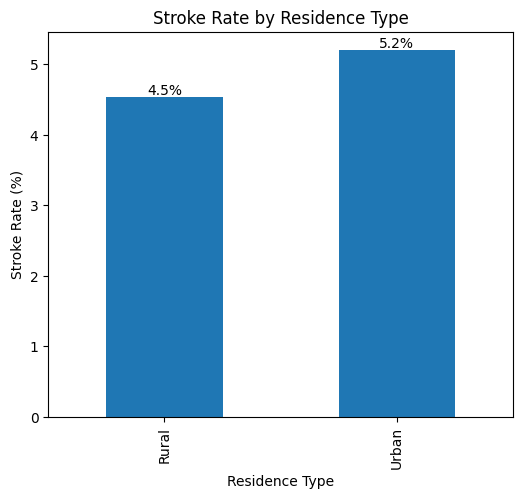

In [92]:
# =====================================================
# VISUALIZE STROKE RATE BY RESIDENCE TYPE
# =====================================================

plt.figure(figsize=(6,5))

ax = residence_stroke_rate.plot(
    kind="bar"
)

plt.title("Stroke Rate by Residence Type")
plt.xlabel("Residence Type")
plt.ylabel("Stroke Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

In [93]:
# =====================================================
# INTERPRETATION OF RESIDENCE TYPE ANALYSIS
# =====================================================

# Stroke prevalence may differ slightly between
# urban and rural populations.

# However, residence type alone is unlikely to
# explain stroke occurrence.

# The observed differences may reflect variations
# in age distribution, healthcare access,
# socioeconomic conditions, and lifestyle factors.

# Residence type may provide additional predictive
# information when combined with other variables.

# **Section 11: Hypertension and Stroke**

# **Business Question**

How does stroke prevalence differ between patients with and without hypertension?

## **Why This Analysis Matters**

Hypertension is one of the most established risk factors for stroke and is frequently associated with increased cardiovascular risk.

Understanding this relationship can help identify whether hypertension is an important predictor within this dataset.

In [94]:
# =====================================================
# CALCULATE STROKE RATE BY HYPERTENSION STATUS
# =====================================================

hypertension_stroke = (
    df.groupby("hypertension")["stroke"]
      .mean()
      * 100
)

hypertension_stroke

,stroke
hypertension,
0,3.967910
1,13.253012


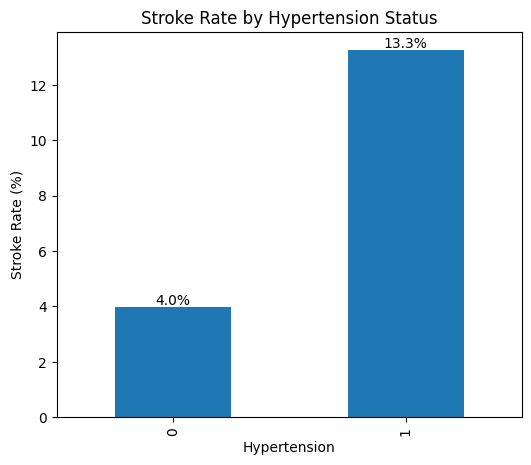

In [95]:
plt.figure(figsize=(6,5))

ax = hypertension_stroke.plot(
    kind="bar"
)

plt.title("Stroke Rate by Hypertension Status")
plt.xlabel("Hypertension")
plt.ylabel("Stroke Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

In [96]:
# =====================================================
# INTERPRETATION OF HYPERTENSION ANALYSIS
# =====================================================

# Patients with hypertension show a substantially
# higher stroke rate than patients without hypertension.

# This finding is consistent with medical evidence
# that elevated blood pressure is strongly associated
# with stroke risk.

# Hypertension appears to be an important predictor
# and should be retained during modelling.

# **Section 12: Heart Disease and Stroke**

## **Business Question**

How does stroke prevalence differ between patients with heart disease and those without heart disease?

## **Why This Analysis Matters**

Heart disease is a major cardiovascular condition that is often associated with increased stroke risk. Both heart disease and stroke share several underlying risk factors, including hypertension, diabetes, and advancing age.

Understanding this relationship helps determine whether heart disease is an important predictor of stroke occurrence in this dataset.

However, the results should be interpreted carefully. This analysis identifies associations rather than proving that heart disease directly causes stroke. Other factors, particularly age and hypertension, may also contribute to the observed differences.

Therefore, this analysis is useful for identifying patterns that may inform feature engineering and predictive modelling.

In [97]:
# =====================================================
# CALCULATE STROKE RATE BY HEART DISEASE STATUS
# =====================================================

# Group patients according to heart disease status.
#
# heart_disease:
# 0 = No Heart Disease
# 1 = Heart Disease
#
# The stroke column is binary:
# 0 = No Stroke
# 1 = Stroke
#
# Taking the mean of the stroke column gives the
# proportion of patients who experienced a stroke.
#
# Multiplying by 100 converts the proportions into
# percentages, making interpretation easier.

heart_stroke_rate = (
    df.groupby("heart_disease")["stroke"]
      .mean()
      * 100
)

# Display stroke rates.

heart_stroke_rate


,stroke
heart_disease,
0,4.178734
1,17.028986


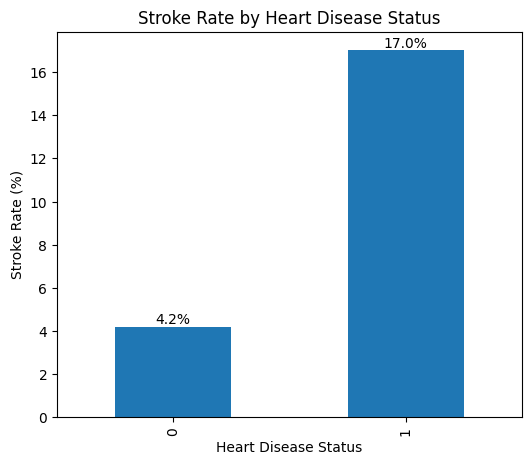

In [98]:
# =====================================================
# VISUALIZE STROKE RATE BY HEART DISEASE STATUS
# =====================================================

plt.figure(figsize=(6,5))

ax = heart_stroke_rate.plot(
    kind="bar"
)

plt.title("Stroke Rate by Heart Disease Status")
plt.xlabel("Heart Disease Status")
plt.ylabel("Stroke Rate (%)")

# Display percentages on top of bars.

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

In [99]:
# =====================================================
# INTERPRETATION OF HEART DISEASE ANALYSIS
# =====================================================

# Patients with heart disease exhibit a substantially
# higher stroke rate than patients without heart disease.

# This finding is consistent with medical knowledge,
# as cardiovascular conditions often share common risk
# factors and biological pathways.

# However, this analysis demonstrates association
# rather than causation.

# Patients with heart disease also tend to be older
# and may have other health conditions such as
# hypertension and elevated glucose levels.

# Therefore, some of the observed relationship may
# be influenced by these underlying factors.

# Nevertheless, heart disease appears to be an
# important clinical predictor and should be retained
# for feature engineering and predictive modelling.

# **Section 13: Glucose Level Distribution**

## **Business Question**

How do glucose levels differ between patients who experienced stroke and those who did not?

## **Why This Analysis Matters**

Elevated glucose levels are associated with diabetes and metabolic disorders, both of which are linked to increased cardiovascular risk.

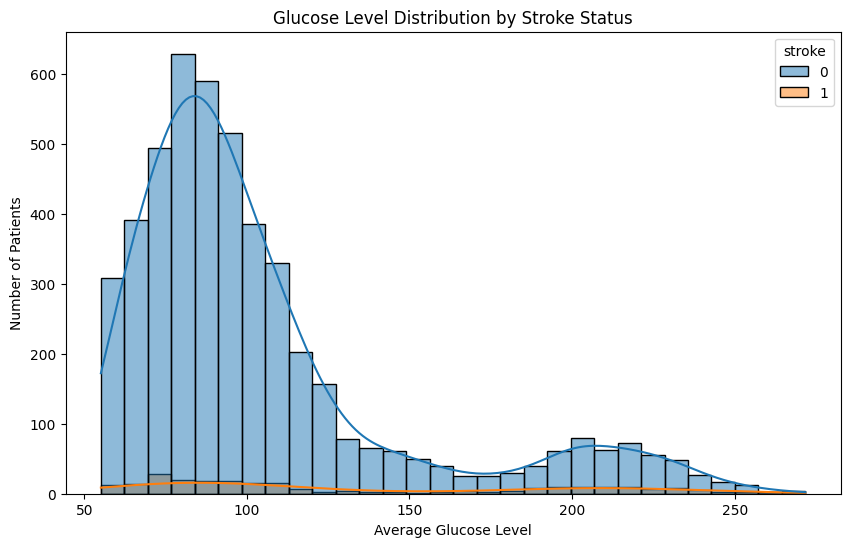

In [100]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="avg_glucose_level",
    hue="stroke",
    kde=True,
    bins=30
)

plt.title("Glucose Level Distribution by Stroke Status")
plt.xlabel("Average Glucose Level")
plt.ylabel("Number of Patients")

plt.show()

In [101]:
# Stroke patients generally exhibit higher glucose
# levels than non-stroke patients.

# The distributions overlap substantially,
# indicating that glucose level alone cannot
# perfectly distinguish stroke cases.

# Nevertheless, elevated glucose appears to be
# an important clinical signal.

# **Section 14: BMI Distribution by Stroke Status**

## **Business Question**

How do BMI distributions differ between patients who experienced a stroke and those who did not?

## **Why This Analysis Matters**

Body Mass Index (BMI) is an important measure of body composition and is commonly used to assess whether an individual is underweight, normal weight, overweight, or obese.

Higher BMI levels are often associated with conditions such as hypertension, diabetes, and cardiovascular disease, which are known risk factors for stroke.

By comparing BMI distributions between stroke and non-stroke patients, we can investigate whether stroke patients tend to have different BMI patterns.

However, BMI alone is unlikely to determine stroke risk. Stroke is a complex condition influenced by multiple demographic, clinical, and lifestyle factors. Therefore, this analysis should be interpreted as identifying associations rather than establishing causation.

The findings may help determine whether BMI should be considered an important feature for predictive modelling.

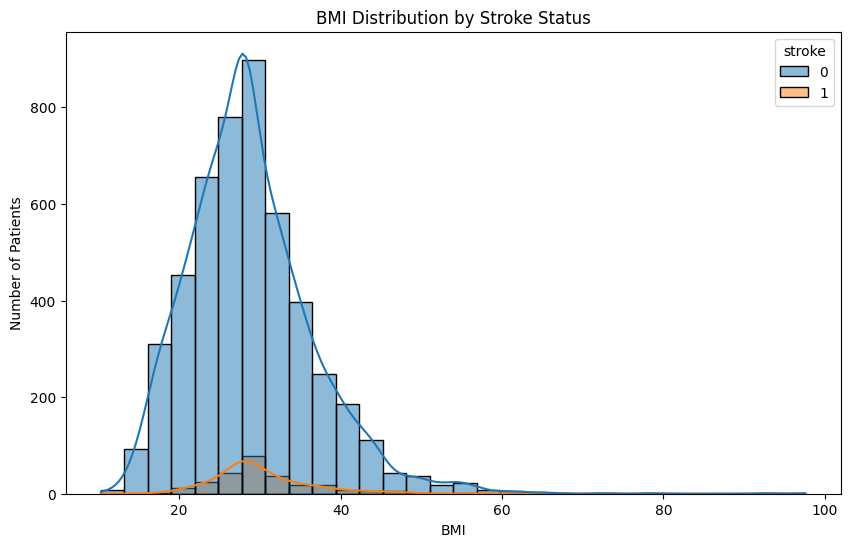

In [102]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="bmi",
    hue="stroke",
    kde=True,
    bins=30
)

plt.title("BMI Distribution by Stroke Status")
plt.xlabel("BMI")
plt.ylabel("Number of Patients")

plt.show()

In [103]:
# Stroke patients tend to have slightly higher
# BMI values than non-stroke patients.

# However, the overlap between both distributions
# suggests that BMI alone is unlikely to perfectly
# predict stroke occurrence.

# BMI may still contribute useful information
# when combined with other variables.

# **Section 15: Smoking Status and Stroke**

## **Business Question**

Does stroke prevalence differ across smoking categories?

## **Why This Analysis Matters**

Smoking is a well-established cardiovascular risk factor and has been linked to increased risk of stroke and other chronic diseases.

The dataset contains multiple smoking categories:
- formerly smoked
- never smoked
- smokes
- Unknown

Examining stroke rates across these groups allows us to explore whether smoking behaviour is associated with differences in stroke prevalence.

However, caution is required when interpreting these results. Smoking status may be related to other variables such as age and overall health condition. For example, older individuals have had more years of potential smoking exposure and may also have higher prevalence of hypertension and heart disease.

Therefore, this analysis identifies patterns and associations rather than direct cause-and-effect relationships.

The findings may provide useful insights for feature engineering and predictive modelling.

In [104]:
smoking_stroke = (
    df.groupby("smoking_status")["stroke"]
      .mean()
      * 100
)

smoking_stroke

,stroke
smoking_status,
Unknown,3.044041
formerly smoked,7.909605
never smoked,4.756871
smokes,5.323194


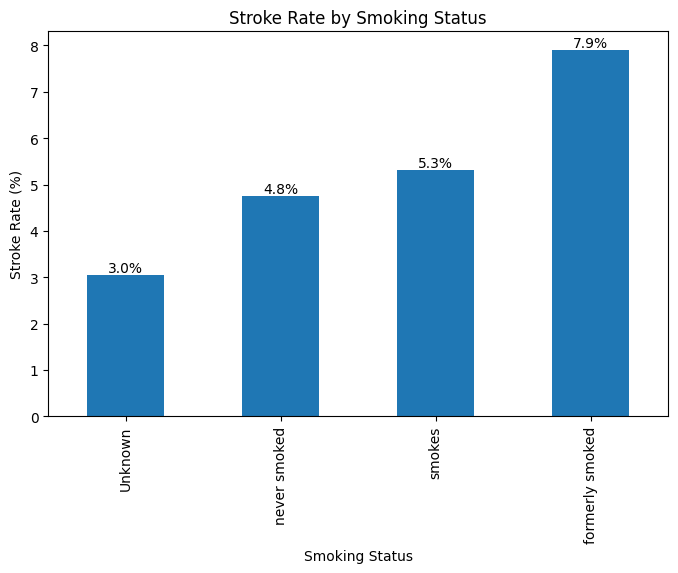

In [105]:
plt.figure(figsize=(8,5))

ax = smoking_stroke.sort_values().plot(
    kind="bar"
)

plt.title("Stroke Rate by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Stroke Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

In [106]:
# Stroke prevalence differs across smoking categories.

# Smoking behaviour appears to have some association
# with stroke occurrence.

# However, age and other health conditions may also
# influence these differences.

# Smoking status should therefore be interpreted as
# one contributing factor rather than a direct cause.

# **Section 16: Correlation Analysis of Numerical Variables**


## **Business Question**

How strongly are the numerical variables related to one another and to stroke occurrence?

## **Why This Analysis Matters**

Correlation analysis measures the strength and direction of linear relationships between numerical variables.

Understanding these relationships is useful because it helps us:

- Identify variables that may be associated with stroke occurrence.
- Detect potential relationships between predictor variables.
- Identify possible multicollinearity issues before predictive modelling.
- Gain insight into which features may contribute useful information during model development.

However, correlation analysis has limitations. Correlation measures only linear relationships and does not imply causation. Variables with weak individual correlations may still become important predictors when combined with other variables within machine learning models.

Therefore, the correlation heatmap should be viewed as an exploratory tool rather than definitive evidence of variable importance.

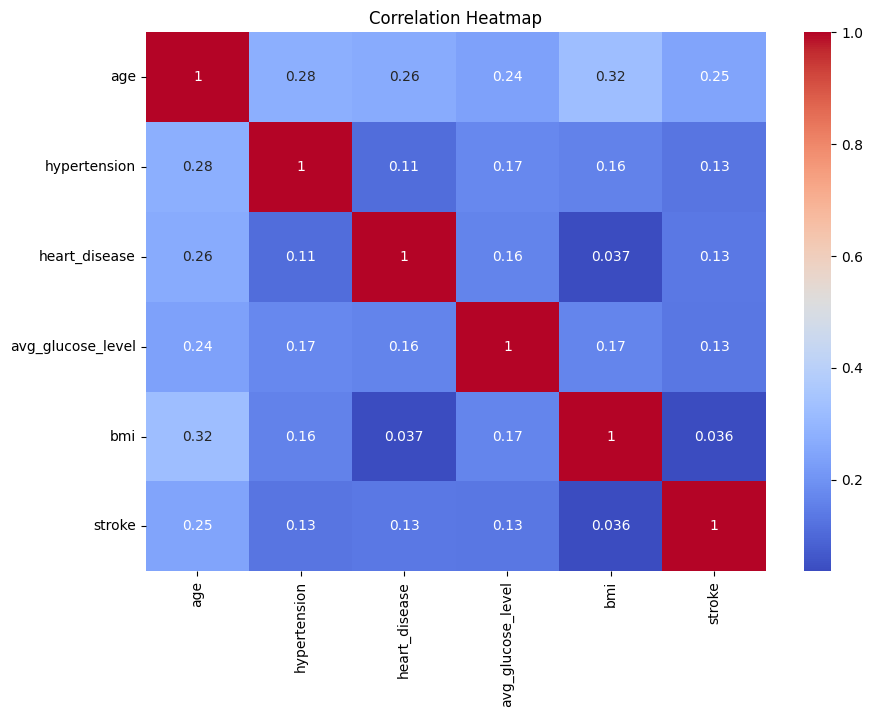

In [107]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [108]:
# Most variables exhibit relatively weak
# linear correlations.

# Age, hypertension, heart disease, and glucose
# appear to have stronger positive relationships
# with stroke than other variables.

# Weak pairwise correlations do not necessarily
# imply weak predictive performance because
# machine learning models can capture
# complex interactions between variables.

# **Section 17: Combined Risk Factor Analysis**

## **Business Question**

How do combinations of demographic and clinical factors influence stroke prevalence?


## **Why This Analysis Matters**

Previous analyses examined individual risk factors separately. However, stroke is a multifactorial condition that usually develops through the interaction of multiple risk factors rather than a single characteristic.

To gain deeper insights, we will investigate several combined analyses:

1. Age Group and Hypertension
2. Hypertension and Heart Disease
3. Glucose Risk Tier and Stroke Rate
4. BMI Category and Stroke Rate

These analyses allow us to determine whether stroke prevalence increases when multiple risk factors occur together.

Combined analyses are particularly important because they help identify high-risk patient profiles and provide insights that may improve predictive modelling and clinical decision-making.

The findings from this section will also help determine which engineered features may contribute meaningful information during model development.



### **Age Group and Hypertension**

Older age and hypertension are both strongly associated with stroke risk. This analysis investigates whether stroke prevalence increases further when these factors occur together.

In [109]:
# =====================================================
# STROKE RATE BY AGE GROUP AND HYPERTENSION
# =====================================================

# Calculate stroke rates for each combination
# of age group and hypertension status.

age_hyper_stroke = (
    pd.crosstab(
        df["age_group"],
        df["hypertension"],
        values=df["stroke"],
        aggfunc="mean"
    ) * 100
)

age_hyper_stroke.round(2)

hypertension,0,1
age_group,,
0-18,0.22,0.00
19-35,0.10,0.00
36-50,1.68,4.00
51-65,5.80,7.26
66+,14.30,22.32


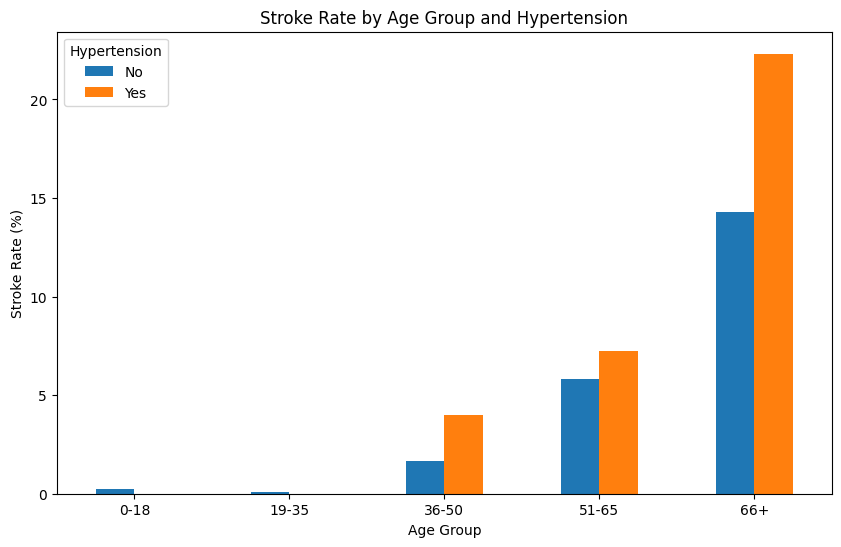

In [110]:
age_hyper_stroke.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Stroke Rate by Age Group and Hypertension")
plt.xlabel("Age Group")
plt.ylabel("Stroke Rate (%)")

plt.legend(
    title="Hypertension",
    labels=["No", "Yes"]
)

plt.xticks(rotation=0)

plt.show()

In [111]:
# INTERPRETATION

# Stroke prevalence increases substantially
# as age increases.

# Within nearly every age group, patients
# with hypertension exhibit higher stroke
# rates than patients without hypertension.

# The combination of older age and
# hypertension appears to represent a
# particularly high-risk patient profile.

# This suggests that interactions between
# demographic and clinical variables may
# improve predictive modelling performance.

In [112]:
# =====================================================
# STROKE RATE BY HYPERTENSION AND HEART DISEASE
# =====================================================

hyper_heart_stroke = (
    pd.crosstab(
        df["hypertension"],
        df["heart_disease"],
        values=df["stroke"],
        aggfunc="mean"
    ) * 100
)

hyper_heart_stroke.round(2)

heart_disease,0,1
hypertension,,
0,3.39,16.04
1,12.21,20.31


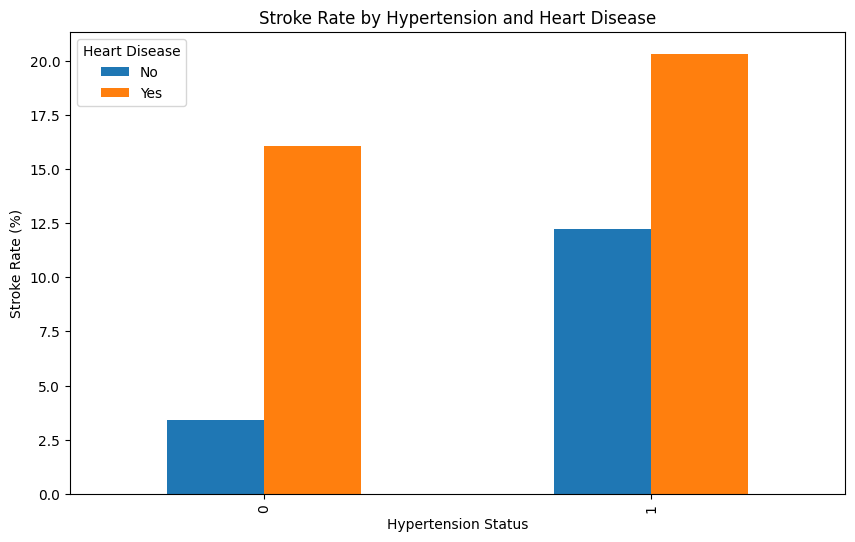

In [113]:
hyper_heart_stroke.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Stroke Rate by Hypertension and Heart Disease")
plt.xlabel("Hypertension Status")
plt.ylabel("Stroke Rate (%)")

plt.legend(
    title="Heart Disease",
    labels=["No", "Yes"]
)

plt.show()

In [114]:
# INTERPRETATION

# Stroke prevalence increases when
# hypertension and heart disease
# occur together.

# Patients with both conditions exhibit
# the highest stroke rates.

# This suggests that multiple
# cardiovascular risk factors may have
# a compounding effect on stroke risk.

# These interactions may provide useful
# information during predictive modelling.

In [115]:
# =====================================================
# CREATE GLUCOSE RISK TIERS
# =====================================================

# Group glucose levels into clinically meaningful categories.

df["glucose_risk_tier"] = pd.cut(
    df["avg_glucose_level"],
    bins=[0, 100, 125, float("inf")],
    labels=[
        "Normal",
        "Pre-diabetic",
        "Diabetic"
    ]
)

# View the first few rows to confirm it worked.

df[["avg_glucose_level", "glucose_risk_tier"]].head()

,avg_glucose_level,glucose_risk_tier
0,228.69,Diabetic
1,202.21,Diabetic
2,105.92,Pre-diabetic
3,171.23,Diabetic
4,174.12,Diabetic


In [118]:
# =====================================================
# STROKE RATE BY GLUCOSE RISK TIER
# =====================================================

# Group patients by glucose risk tier.

# stroke is binary:
# 0 = No Stroke
# 1 = Stroke

# The mean of a binary variable gives
# the proportion of patients who had a stroke.

glucose_stroke = (
    df.groupby("glucose_risk_tier")["stroke"]
      .mean()
      * 100
)

# Display the results.

glucose_stroke.round(2)



/tmp/ipykernel_1877/2100781972.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("glucose_risk_tier")["stroke"]


,stroke
glucose_risk_tier,
Normal,3.58
Pre-diabetic,3.78
Diabetic,10.00


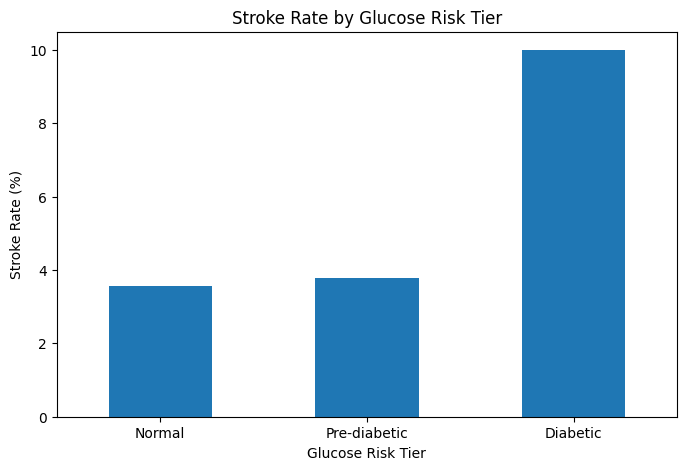

In [119]:
plt.figure(figsize=(8,5))

glucose_stroke.plot(
    kind="bar"
)

plt.title("Stroke Rate by Glucose Risk Tier")
plt.xlabel("Glucose Risk Tier")
plt.ylabel("Stroke Rate (%)")

plt.xticks(rotation=0)

plt.show()

In [ ]:
# INTERPRETATION

# Stroke prevalence generally increases
# as glucose risk increases.

# Patients in the diabetic category
# exhibit the highest stroke rates.

# Elevated glucose levels therefore
# appear to be an important clinical
# indicator of stroke risk.

# Glucose-related features should be
# considered important candidates for
# predictive modelling.

In [123]:
# =====================================================
# CREATE BMI CATEGORIES
# =====================================================

# Group BMI values into standard clinical categories.
#
# Underweight: BMI less than 18.5
# Normal: BMI between 18.5 and 25
# Overweight: BMI between 25 and 30
# Obese: BMI greater than 30

df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, float("inf")],
    labels=[
        "Underweight",
        "Normal",
        "Overweight",
        "Obese"
    ]
)

# Check that the categories were created correctly.

df[["bmi", "bmi_category"]].head()

,bmi,bmi_category
0,36.6,Obese
1,28.1,Overweight
2,32.5,Obese
3,34.4,Obese
4,24.0,Normal


In [124]:
# =====================================================
# STROKE RATE BY BMI CATEGORY
# =====================================================

# Group patients according to BMI category.
#
# stroke is binary:
# 0 = No Stroke
# 1 = Stroke
#
# Taking the mean gives the proportion
# of patients who experienced stroke.

bmi_stroke = (
    df.groupby("bmi_category")["stroke"]
      .mean()
      * 100
)

# Display stroke rates.

bmi_stroke.round(2)

/tmp/ipykernel_1877/3548317684.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("bmi_category")["stroke"]


,stroke
bmi_category,
Underweight,0.29
Normal,2.94
Overweight,7.14
Obese,5.07


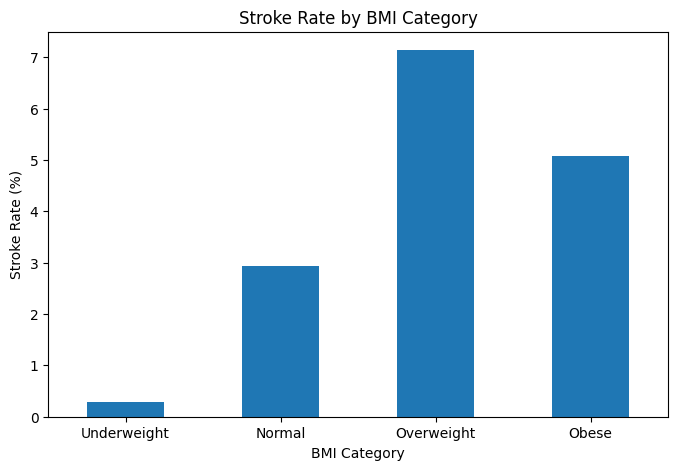

In [125]:
plt.figure(figsize=(8,5))

bmi_stroke.plot(
    kind="bar"
)

plt.title("Stroke Rate by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Stroke Rate (%)")

plt.xticks(rotation=0)

plt.show()

In [ ]:
# INTERPRETATION

# Stroke prevalence differs across BMI categories.

# Higher BMI categories generally exhibit
# higher stroke rates than lower BMI categories.

# However, the differences are smaller than
# those observed for age, hypertension,
# and glucose risk.

# This suggests that BMI may contribute
# additional predictive information but is
# unlikely to be the strongest independent
# predictor of stroke occurrence.

# BMI should therefore be considered
# alongside other demographic and clinical
# variables during predictive modelling.

# **Section 18: Final EDA Summary**


**Final EDA Summary**

The exploratory data analysis revealed several important patterns associated with stroke occurrence in the dataset.


**Age** emerged as the strongest predictor of stroke occurrence. Stroke rates increased substantially with age, with patients aged 66 years and above exhibiting the highest prevalence of stroke.


**Hypertension and heart disease** were associated with considerably higher stroke rates. Patients with these cardiovascular conditions experienced stroke more frequently than those without these conditions.


**Elevated glucose levels** were linked to increased stroke risk. Patients in the diabetic glucose risk tier showed higher stroke prevalence, suggesting that metabolic health plays an important role in stroke risk assessment.
BMI demonstrated some relationship with stroke occurrence, although its effect appeared weaker than age and cardiovascular factors. Higher BMI categories generally exhibited higher stroke rates but did not show as strong an association as age or hypertension.


**Some demographic variables, such as marital status and work type**, may be influenced by age differences within the dataset. Therefore, these variables should not be interpreted as direct causes of stroke risk because age may act as a confounding factor.


**Implications for Predictive Modelling**

The findings suggest that demographic characteristics (particularly age), cardiovascular conditions (hypertension and heart disease), and metabolic indicators (glucose level and BMI) should receive greater attention during feature engineering and predictive modelling. Additionally, interactions between variables, such as age combined with hypertension and hypertension combined with heart disease, may provide valuable predictive information and should be considered during model development.